In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')

In [2]:
import sys
sys.path.append('../')
from src import dataloader 
from models import configs

In [3]:
data_loader_training, data_loader_validate, data_loader_test = dataloader.get_dataloaders(
    batch_size = 1, 
    img_size = 16,
    in_channels = 8, 
    resmapling_status = configs.to_bool(False),
    data = 's2',
    exp_name = 'weight'
    )

(13875, 36) | (8233, 36) | (12443, 36)


In [7]:
data_loader_training_csr1, data_loader_validate_csr1, data_loader_test_csr1 = dataloader.get_dataloaders(
    batch_size = 1, 
    img_size = 16,
    in_channels = 8, 
    resmapling_status = configs.to_bool(True),
    data = 's2',
    exp_name = 'weight'
    )

(13875, 36) | (8233, 36) | (12443, 36)
resampling is True, The dataloader is processing cost-sensitive resampling!


In [4]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_sample_count_by_bins(df1, df2):
    # Define bins between 0 and 30 with an interval of 3
    bins = [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30]
    
    # Create a 'bin' column in both dataframes based on the patch_mean column
    df1['bin'] = pd.cut(df1['patch_mean'], bins=bins, include_lowest=True)
    df2['bin'] = pd.cut(df2['patch_mean'], bins=bins, include_lowest=True)
    
    # Group by bins and calculate the count of samples for each bin
    count_samples_df1 = df1.groupby('bin').size()
    count_samples_df2 = df2.groupby('bin').size()
    
    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot for df1
    axes[0].bar(count_samples_df1.index.astype(str), count_samples_df1, color='skyblue')
    axes[0].set_title('Strategy 1 - Sample Count per Bin')
    axes[0].set_xlabel('Bins (Patch Mean)')
    axes[0].set_ylabel('Sample Count')
    axes[0].set_xticklabels(count_samples_df1.index.astype(str), rotation=45)
    axes[0].grid(True)

    # Plot for df2
    axes[1].bar(count_samples_df2.index.astype(str), count_samples_df2, color='lightgreen')
    axes[1].set_title('Strategy 2 - Sample Count per Bin')
    axes[1].set_xlabel('Bins (Patch Mean)')
    axes[1].set_ylabel('Sample Count')
    axes[1].set_xticklabels(count_samples_df2.index.astype(str), rotation=45)
    axes[1].grid(True)
    
    # Display the plots
    plt.tight_layout()
    plt.show()

def create_dataframe_from_dataloader(dataloader):
    data = []

    # Loop through each batch in the dataloader
    for sample in dataloader:
        # Calculate patch_mean
        patch_mean = sample['mask'].mean().item()
        
        # Extract block and cultivar
        block = sample['block']
        cultivar = sample['cultivar']

        # Append data to the list
        data.append({
            'block': block,
            'cultivar': cultivar,
            'patch_mean': patch_mean
        })

    # Convert list to dataframe
    df = pd.DataFrame(data)

    return df

In [5]:
df_raw = create_dataframe_from_dataloader(data_loader_training)

In [12]:

df_csr1 = create_dataframe_from_dataloader(data_loader_training_csr1)

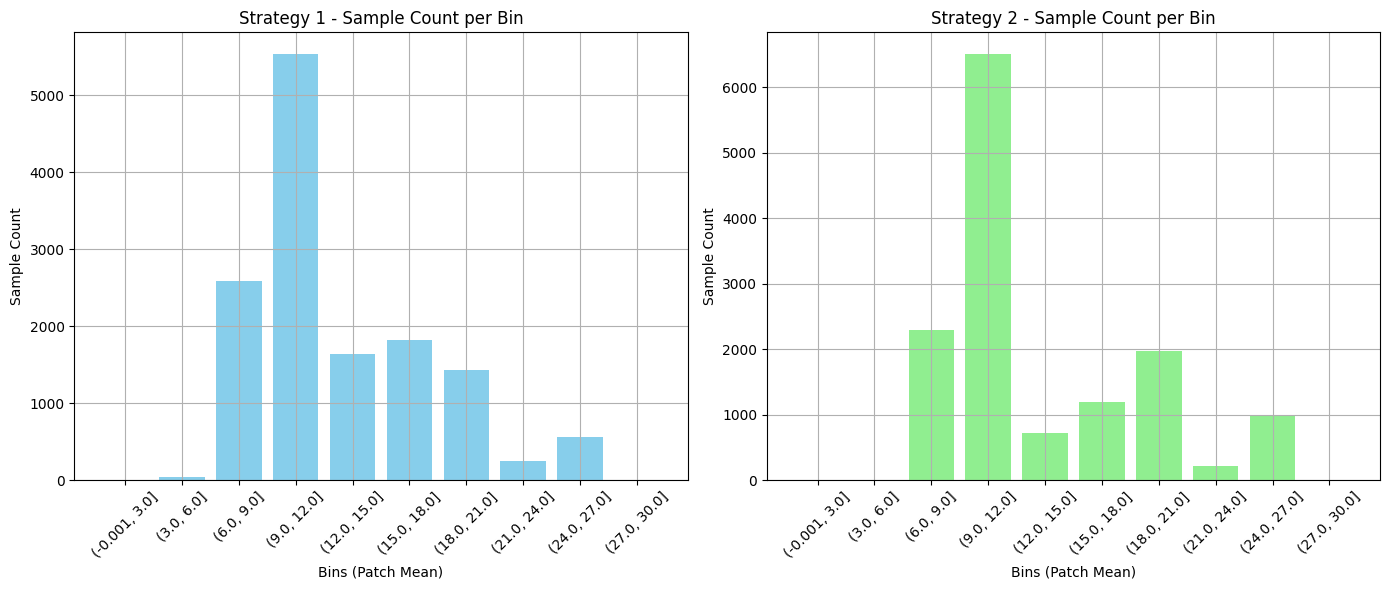

In [18]:
plot_sample_count_by_bins(df_raw, df_csr1)

In [19]:
data_loader_training_csr2, data_loader_validate_csr2, data_loader_test_csr2 = dataloader.get_dataloaders(
    batch_size = 1, 
    img_size = 16,
    in_channels = 8, 
    resmapling_status = configs.to_bool(True),
    data = 's2',
    exp_name = 'weight'
    )

(13875, 36) | (8233, 36) | (12443, 36)
resampling is True, The dataloader is processing cost-sensitive resampling!


In [20]:
df_csr2 = create_dataframe_from_dataloader(data_loader_training_csr2)

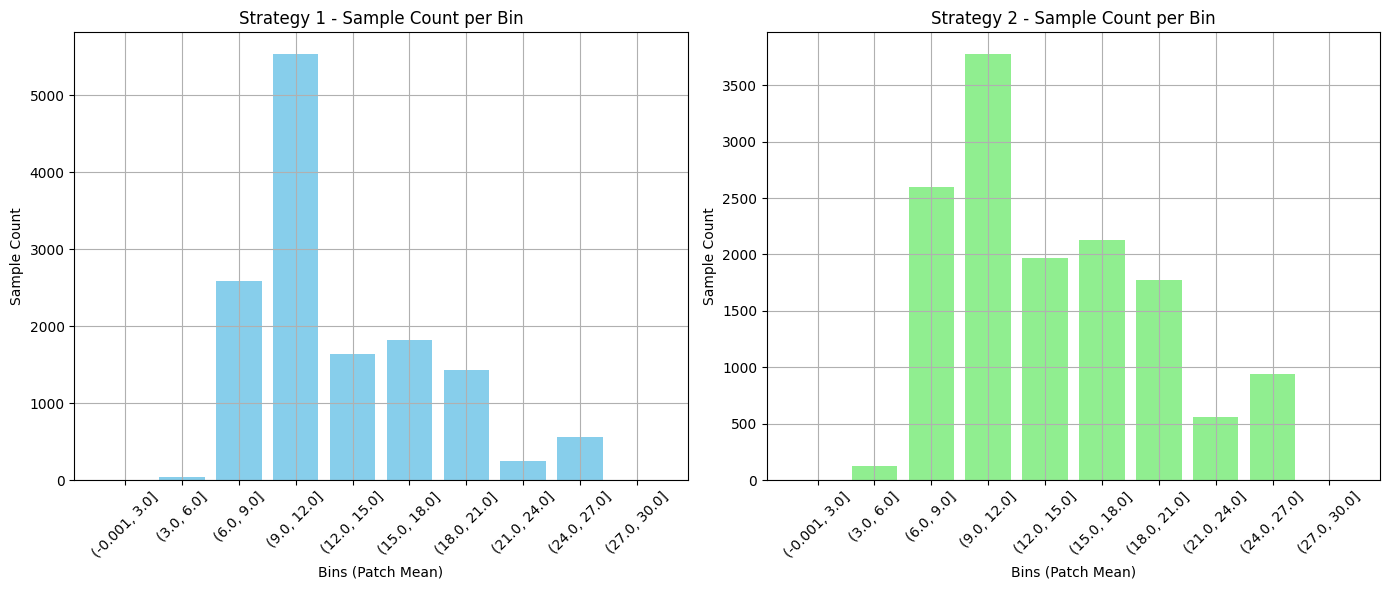

In [21]:
plot_sample_count_by_bins(df_raw, df_csr2)

In [7]:
data_loader_training_csr3, data_loader_validate_csr3, data_loader_test_csr3 = dataloader.get_dataloaders(
    batch_size = 1, 
    img_size = 16,
    in_channels = 8, 
    resmapling_status = configs.to_bool(True),
    data = 's2',
    exp_name = 'weight'
    )

(13875, 36) | (8233, 36) | (12443, 36)
resampling is True, The dataloader is processing cost-sensitive resampling!


In [8]:
df_csr3 = create_dataframe_from_dataloader(data_loader_training_csr3)

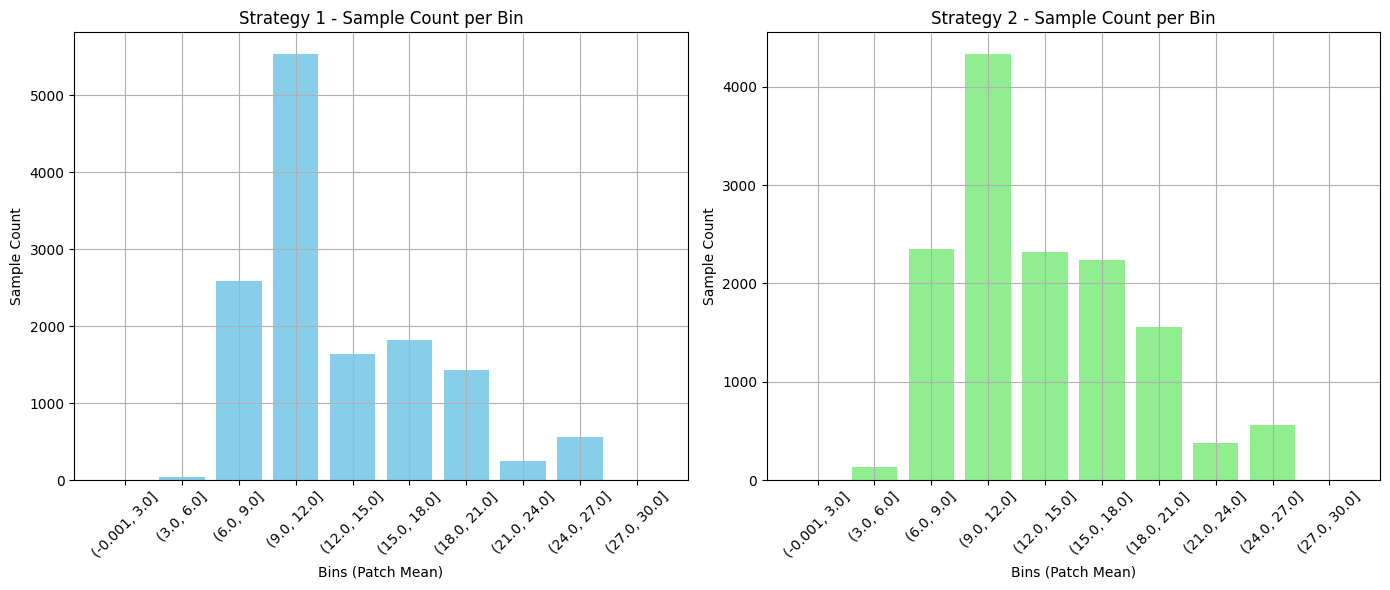

In [9]:
plot_sample_count_by_bins(df_raw, df_csr3)

In [10]:
data_loader_training_csr4, data_loader_validate_csr4, data_loader_test_csr4 = dataloader.get_dataloaders(
    batch_size = 1, 
    img_size = 16,
    in_channels = 8, 
    resmapling_status = configs.to_bool(True),
    data = 's2',
    exp_name = 'weight'
    )

(13875, 36) | (8233, 36) | (12443, 36)
resampling is True, The dataloader is processing cost-sensitive resampling!


In [11]:
df_csr4 = create_dataframe_from_dataloader(data_loader_training_csr4)

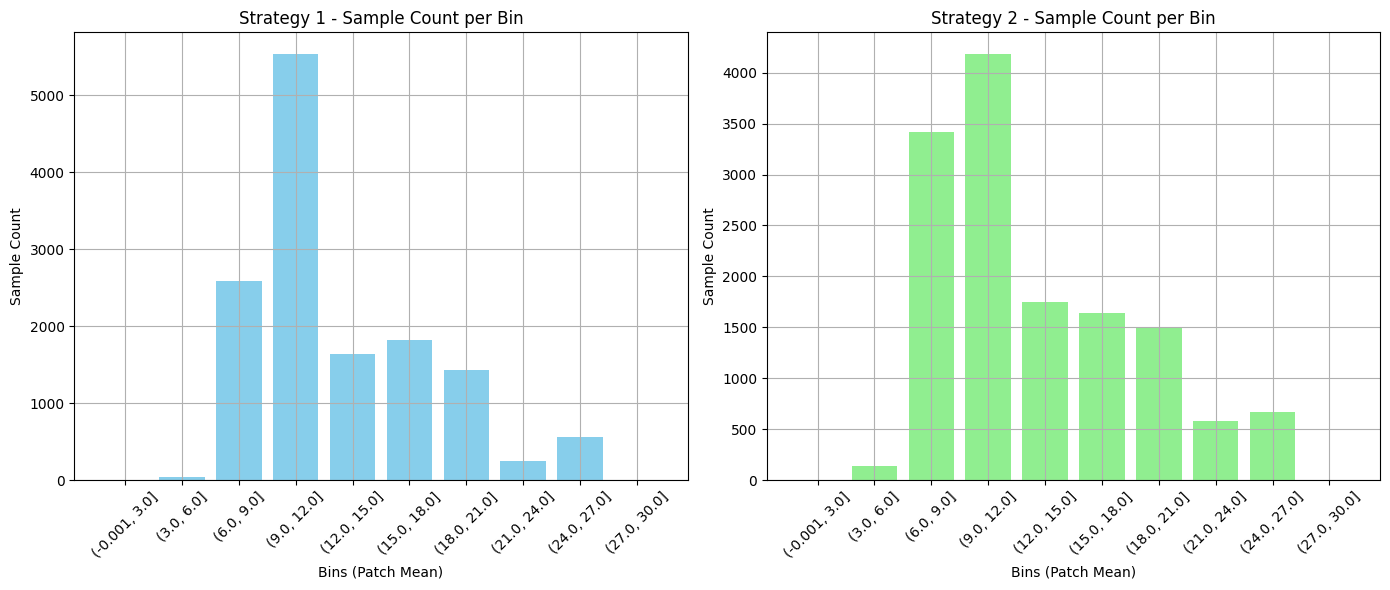

In [12]:
plot_sample_count_by_bins(df_raw, df_csr4)